In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load cleaned data
df = pd.read_csv("GlobalWeatherRepository_cleaned.csv", parse_dates=["last_updated"])

# basic statistics
stats = df.describe()
stats

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,106403.000000,106403.000000,1.064030e+05,106403,106403.000000,106403.000000,106403.000000,106403.000000,106403.00000,106403.000000,...,106403.000000,106403.000000,106403.000000,106403.000000,106403.000000,106403.000000,106403.000000,106403.000000,106403.000000,106403.00000
mean,19.166354,22.053276,1.739533e+09,2025-02-14 13:40:31.860004096,22.591333,72.666165,8.161494,13.138062,170.73981,1014.030347,...,18.375135,501.198713,61.430553,15.620781,10.988174,25.374501,51.511216,1.734350,2.694529,50.28705
min,-41.300000,-175.200000,1.715849e+09,2024-05-16 01:45:00,-24.900000,-12.800000,2.200000,3.600000,1.00000,947.000000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.00000
25%,3.750000,-6.836100,1.727776e+09,2024-10-01 05:45:00,17.600000,63.700000,4.000000,6.500000,83.00000,1010.000000,...,10.400000,227.000000,41.000000,1.480000,0.925000,7.250000,10.500000,1.000000,1.000000,16.00000
50%,17.250000,23.316700,1.739527e+09,2025-02-14 22:00:00,24.500000,76.100000,6.900000,11.200000,164.00000,1013.000000,...,15.700000,318.200000,58.000000,5.150000,2.405000,14.615000,21.275000,1.000000,2.000000,51.00000
75%,40.400000,50.580000,1.751360e+09,2025-07-01 11:00:00,28.300000,82.900000,11.200000,18.000000,256.00000,1018.000000,...,24.300000,494.000000,78.000000,17.945000,8.880000,28.860000,43.925000,2.000000,3.000000,85.00000
max,64.150000,179.220000,1.763105e+09,2025-11-14 20:30:00,49.200000,120.600000,1841.200000,2963.200000,360.00000,3006.000000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.00000
std,24.445309,65.805201,1.366618e+07,NaN,8.857882,15.943994,7.675802,12.350380,102.69542,11.060985,...,14.381609,821.409368,31.821593,25.433469,39.280192,39.591201,158.749761,0.967086,2.520785,35.00406


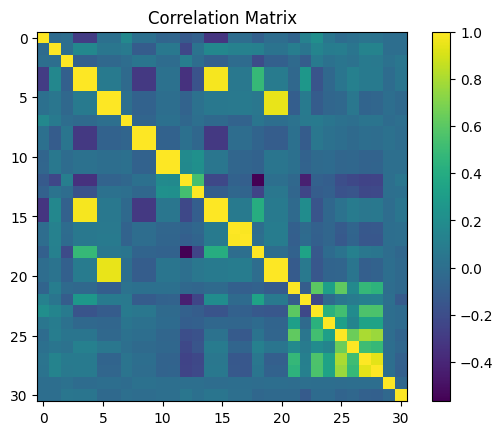

In [7]:
#correlation :
corr = df.select_dtypes("number").corr()
corr
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

In [8]:
#comparing weather between countries
region_avg = df.groupby("country")[
    ["temperature_celsius", "humidity", "wind_kph"]
].mean()

region_avg.head()

region_avg["temperature_celsius"].sort_values(ascending=False).head(10)

country
Saudi Arabien           45.000000
Marrocos                40.300000
Turkménistan            37.800000
Qatar                   34.438828
United Arab Emirates    34.259598
Kuwait                  34.218464
Турция                  34.000000
Saudi Arabia            33.821651
Djibouti                32.831927
Oman                    32.567642
Name: temperature_celsius, dtype: float64

In [9]:
#extreme plots/outliers
# extreme temperature (top 5%)
temp_threshold = df["temperature_celsius"].quantile(0.95)

extreme_temp = df[df["temperature_celsius"] >= temp_threshold]
extreme_temp.head(10)

extreme_temp[[
    "country",
    "last_updated",
    "temperature_celsius"
]].head(10)


,country,last_updated,temperature_celsius
12,Bahrain,2024-05-16 11:45:00,36.0
13,Bangladesh,2024-05-16 14:45:00,38.4
30,Cambodia,2024-05-16 15:45:00,38.0
34,Chad,2024-05-16 09:45:00,37.2
77,India,2024-05-16 14:15:00,42.0
118,Myanmar,2024-05-16 15:15:00,37.5
131,Pakistan,2024-05-16 13:45:00,38.2
138,Philippines,2024-05-16 16:45:00,35.0
141,Qatar,2024-05-16 11:45:00,37.0
151,Saudi Arabia,2024-05-16 11:45:00,39.0


In [10]:
#extreme plots/outliers
# extreme temperature (top 5%)
temp_threshold = df["temperature_celsius"].quantile(0.95)

extreme_temp = df[df["temperature_celsius"] >= temp_threshold]
extreme_temp.head(10)

extreme_temp[[
    "country",
    "last_updated",
    "temperature_celsius"
]].head(10)


,country,last_updated,temperature_celsius
12,Bahrain,2024-05-16 11:45:00,36.0
13,Bangladesh,2024-05-16 14:45:00,38.4
30,Cambodia,2024-05-16 15:45:00,38.0
34,Chad,2024-05-16 09:45:00,37.2
77,India,2024-05-16 14:15:00,42.0
118,Myanmar,2024-05-16 15:15:00,37.5
131,Pakistan,2024-05-16 13:45:00,38.2
138,Philippines,2024-05-16 16:45:00,35.0
141,Qatar,2024-05-16 11:45:00,37.0
151,Saudi Arabia,2024-05-16 11:45:00,39.0


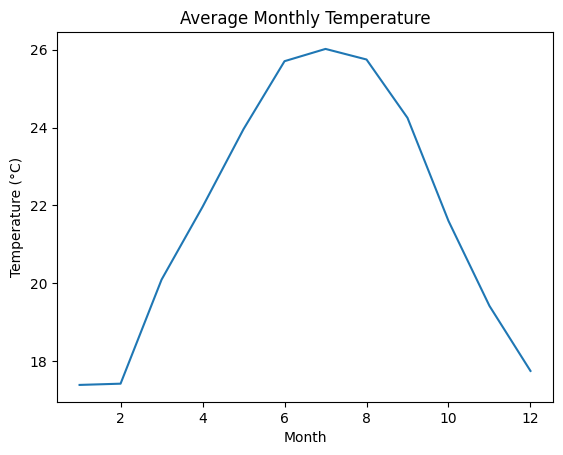

In [11]:
#Seasonal patterns:
df["month"] = df["last_updated"].dt.month

monthly_avg = df.groupby("month")["temperature_celsius"].mean()
monthly_avg
monthly_avg.plot(title="Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()